In [1]:
!pip install tensorflow==2.12.0
!pip install keras

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 3.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 84.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 87.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 21.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: wrapt
    Found ex

Found 10766 files belonging to 5 classes.
Using 9690 files for training.
Found 10766 files belonging to 5 classes.
Using 1076 files for validation.
Classes: ['Bacterial Leaf Blight', 'Healthy _leaf', 'Rice', 'Rice Blast', 'Tungro']
Number of classes: 5


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


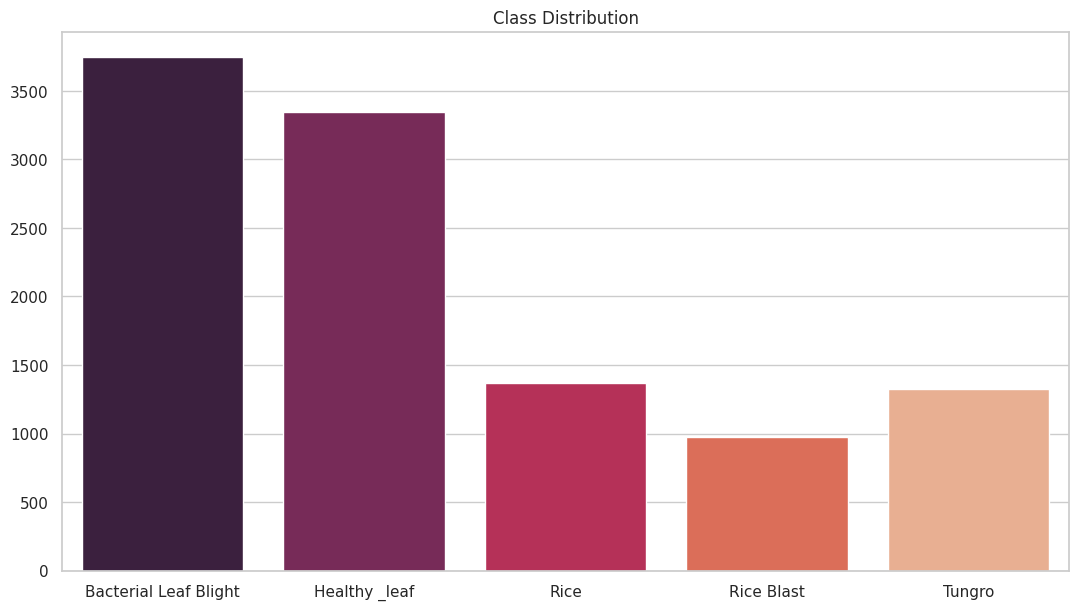

Weight for class 0 (Bacterial Leaf Blight): 0.57
Weight for class 1 (Healthy _leaf): 0.64
Weight for class 2 (Rice): 1.57
Weight for class 3 (Rice Blast): 2.20
Weight for class 4 (Tungro): 1.62


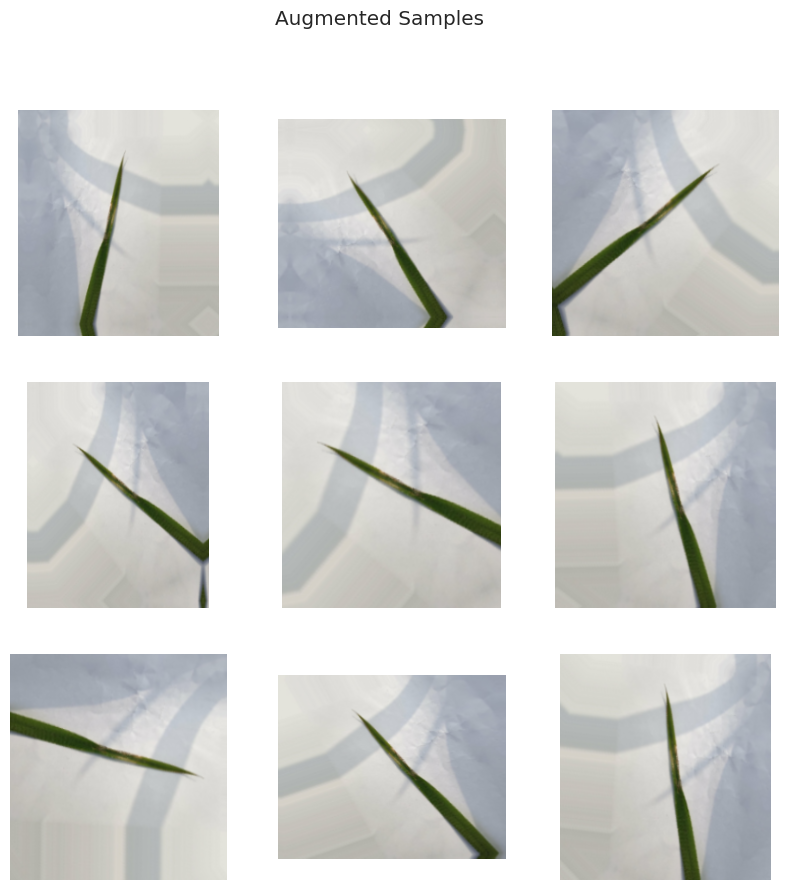

94765736/94765736 [==============================] - 3s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential (Sequential)     (None, None, None, 3)     0         
                                                                 
 tf.__operators__.getitem (S  (None, None, None, 3)    0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, None, None, 3)    0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0      

In [2]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
directory = "/kaggle/input/rice-leaf-and-crop-disease-detection-dataset/Rice Leaf and Crop Disease Detection Dataset"

# Load datasets
train_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.1,
    subset='training',
    seed=42
)
validation_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.1,
    subset='validation',
    seed=42
)

# Get class names and number of classes
class_names = train_dataset.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

# Plot class distribution
sns.set_theme(style="whitegrid")
Data_imbalance = []
for folder in os.listdir(directory):
    files = gb.glob(pathname=os.path.join(directory, folder, "*.*"))
    Data_imbalance.append(len(files))

plt.figure(figsize=(13, 7))
sns.barplot(x=class_names, y=Data_imbalance, palette="rocket")
plt.title("Class Distribution")
plt.show()

# Calculate class weights dynamically
total = sum(Data_imbalance)
class_weight = {
    i: (1 / count) * (total / num_classes)
    for i, count in enumerate(Data_imbalance)
}

# Print class weights
for idx, weight in class_weight.items():
    print(f"Weight for class {idx} ({class_names[idx]}): {weight:.2f}")

# Data augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
])

# Visualize augmented images
for image_batch, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    image = image_batch[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        aug_img = data_augmentation(tf.expand_dims(image, 0))
        plt.imshow(aug_img[0] / 255)
        plt.axis('off')
    plt.suptitle("Augmented Samples")
    plt.show()

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

# Load base ResNet50
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False

# Build full model
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

# Compile
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    class_weight=class_weight,
    verbose=2
)


17/17 [==============================] - 76s 4s/step - loss: 0.7375 - accuracy: 0.7193

Validation Loss: 0.7375
Validation Accuracy: 0.7193


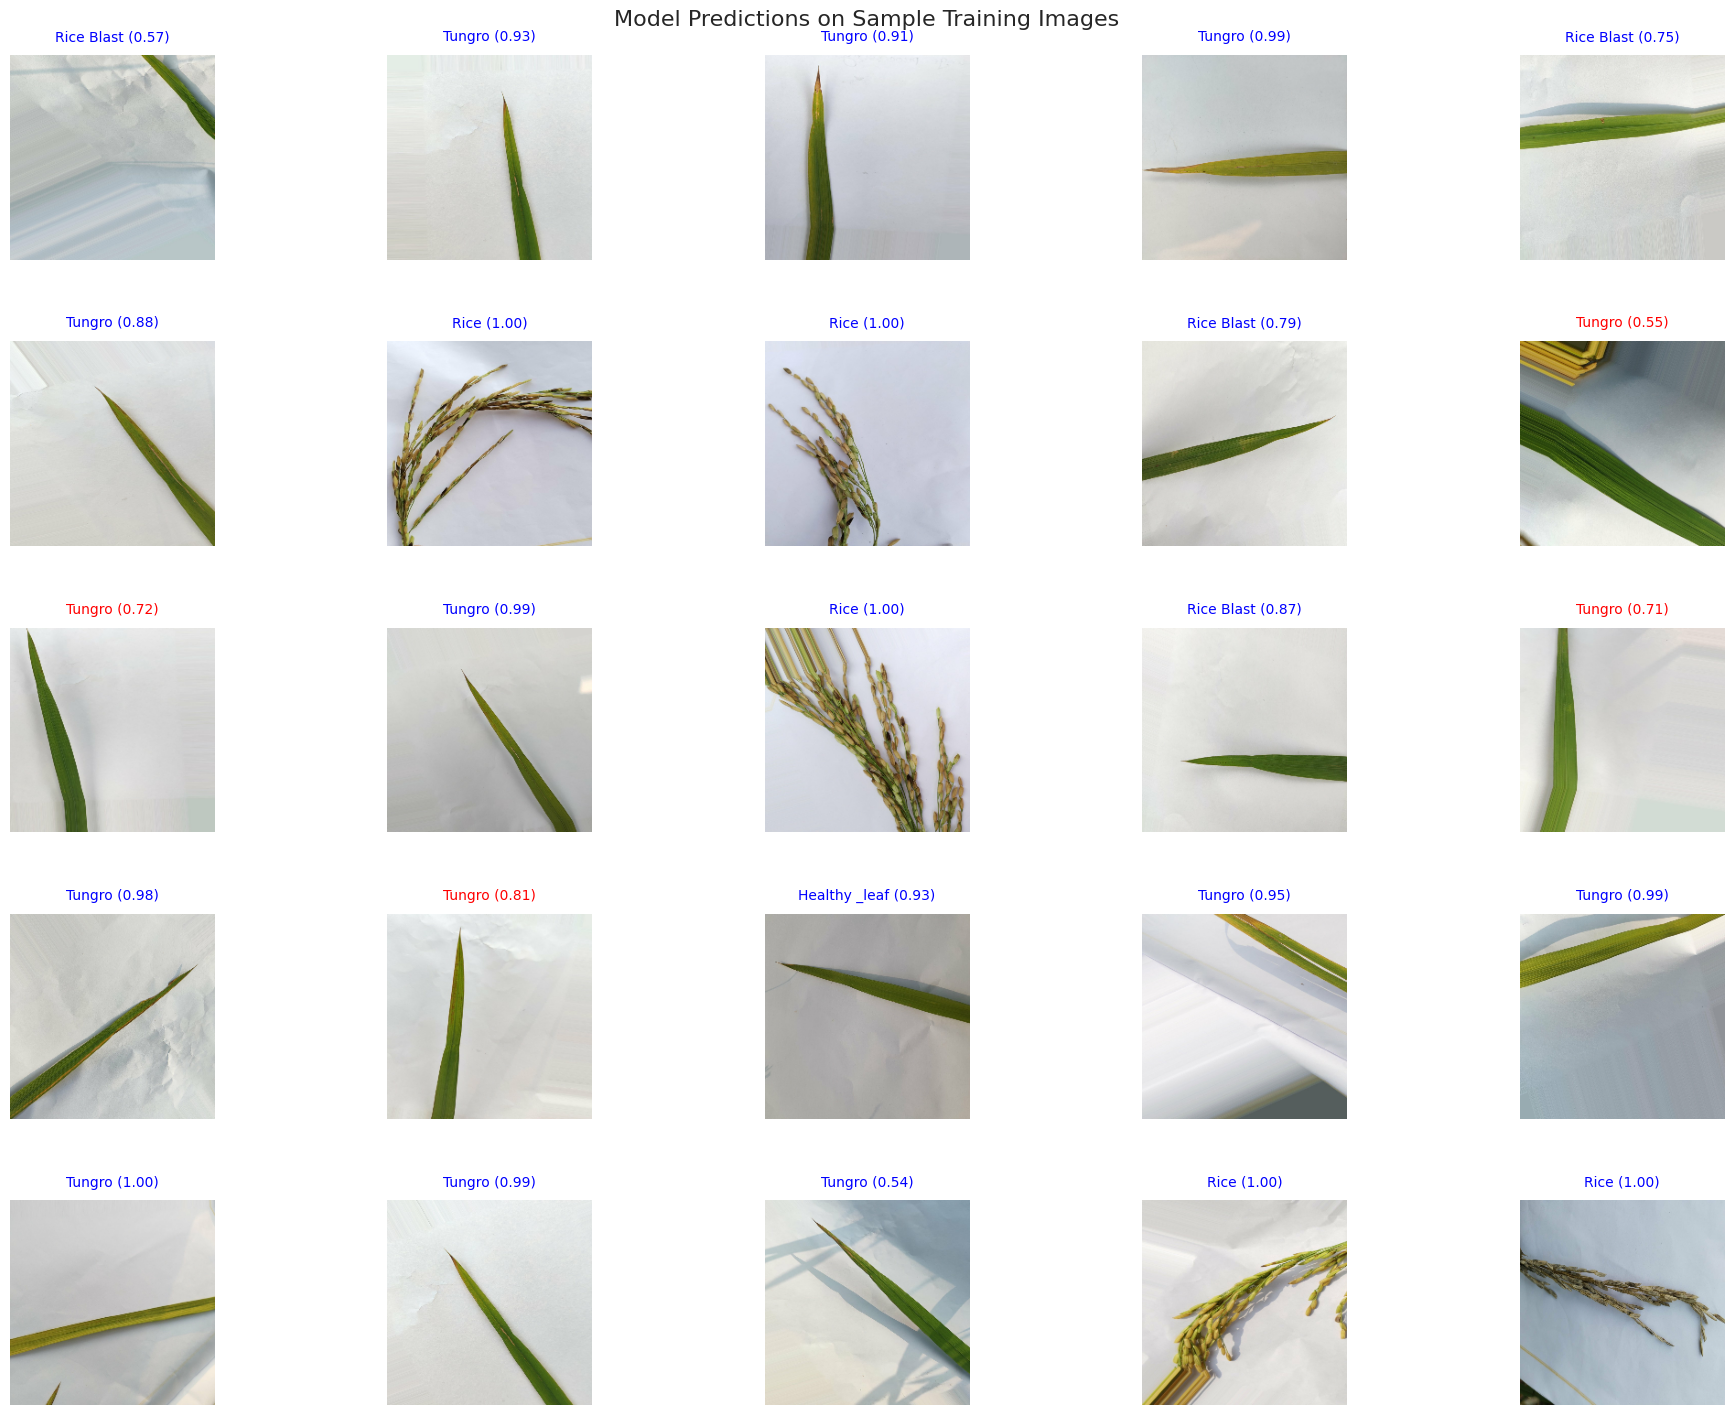

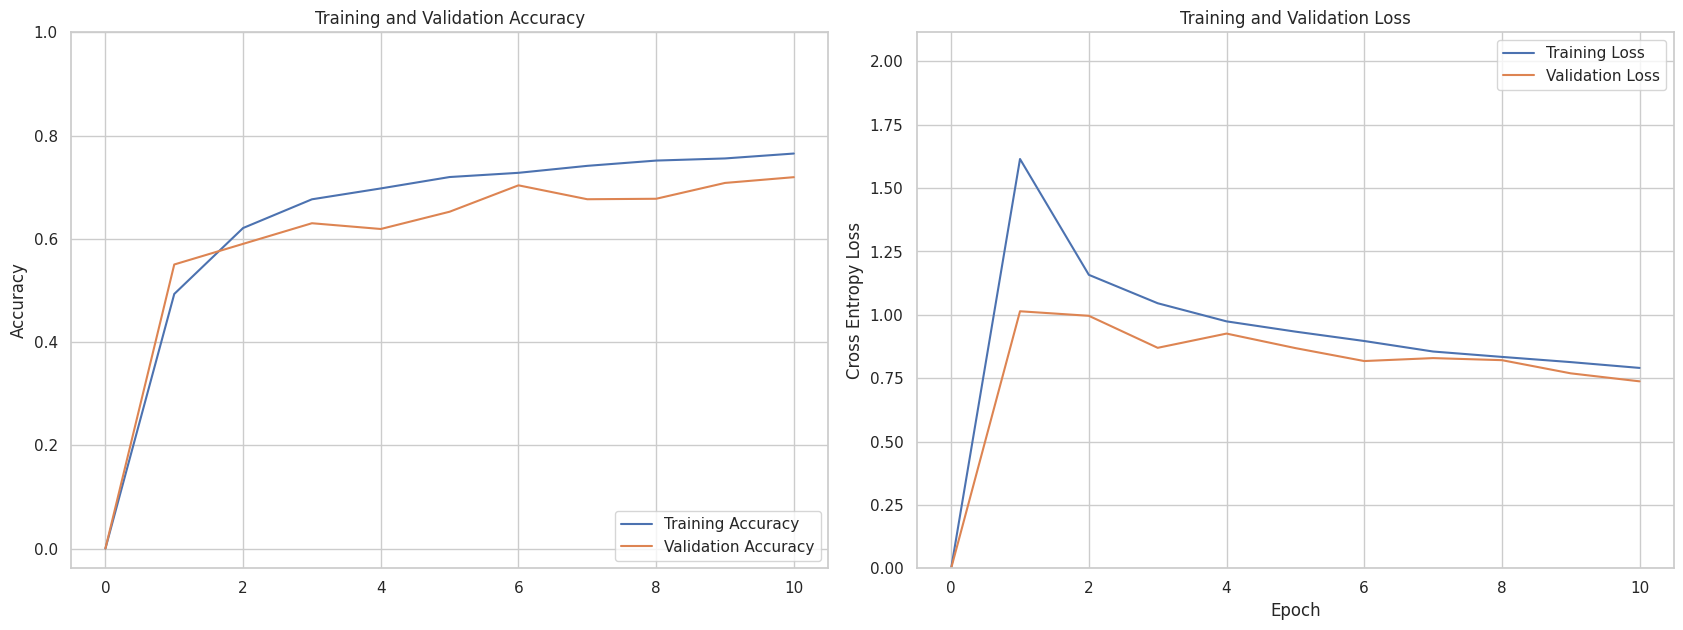

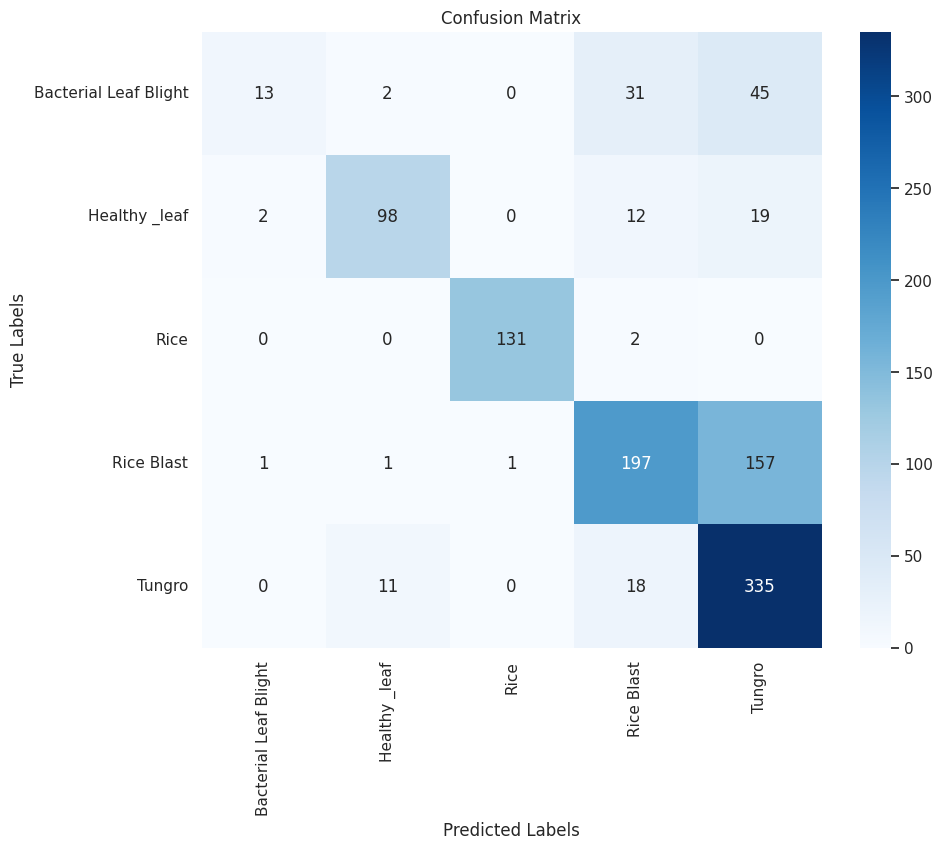

Confusion Matrix:
 [[ 13   2   0  31  45]
 [  2  98   0  12  19]
 [  0   0 131   2   0]
 [  1   1   1 197 157]
 [  0  11   0  18 335]]

Classification Report:

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.81      0.14      0.24        91
        Healthy _leaf       0.88      0.75      0.81       131
                 Rice       0.99      0.98      0.99       133
           Rice Blast       0.76      0.55      0.64       357
               Tungro       0.60      0.92      0.73       364

             accuracy                           0.72      1076
            macro avg       0.81      0.67      0.68      1076
         weighted avg       0.75      0.72      0.70      1076



In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# -------------------------------
# ✅ 1. Evaluate the Model
# -------------------------------
validation_loss, validation_accuracy = model.evaluate(validation_dataset, verbose=1)

print(f"\nValidation Loss: {validation_loss:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")

# -------------------------------
# ✅ 2. Visualize Predictions on Sample Training Images
# -------------------------------
plt.figure(figsize=(20, 15))

for images, labels in train_dataset.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)

        image = images[i]
        label = labels[i].numpy()

        img_array = tf.expand_dims(image, 0)  # Shape: (1, 224, 224, 3)
        prediction = model.predict(img_array, verbose=0)
        predicted_class = class_names[np.argmax(prediction)]
        actual_class = class_names[label]

        plt.imshow(image.numpy().astype("uint8"))
        plt.axis("off")

        # Title color
        color = 'blue' if predicted_class == actual_class else 'red'
        confidence = np.max(prediction)
        plt.title(f"{predicted_class} ({confidence:.2f})", fontsize=10, color=color, pad=10)

    plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95,
                        top=0.95, wspace=0.3, hspace=0.4)
plt.suptitle("Model Predictions on Sample Training Images", fontsize=16)
plt.show()

# -------------------------------
# ✅ 3. Plot Accuracy and Loss
# -------------------------------
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = [0.] + history.history['loss']
val_loss = [0.] + history.history['val_loss']

plt.figure(figsize=(17, 12))

# Accuracy Plot
plt.subplot(2, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()), 1])
plt.title('Training and Validation Accuracy')

# Loss Plot
plt.subplot(2, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy Loss')
plt.ylim([0, max(max(loss), max(val_loss)) + 0.5])
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')

plt.tight_layout()
plt.show()

# -------------------------------
# ✅ 4. Confusion Matrix & Classification Report
# -------------------------------
true_labels = []
predicted_labels = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_classes)

# Compute Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Print Confusion Matrix and Classification Report
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_names))
